In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
plt.style.use('seaborn')
sns.set(font_scale=2)
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.set_random_seed(777)
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_train = pd.read_csv('./data/train.csv')
# df_test = pd.read_csv('./data/test.csv')

In [3]:
df_train.head()

,date&time,WashingMachine,Dryer,temp,icon,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
0,2014-01-01 0:00,0.005686,0.005231,16.67,clear-night,0.53,10.0,Clear,3.95,1022.69,11.23,0.00,1388552400,271.0,0.0,2.41,0.0,3
1,2014-01-01 1:00,0.005635,0.005293,16.19,clear-night,0.52,10.0,Clear,4.18,1022.58,9.92,0.02,1388556000,268.0,0.0,1.68,0.0,3
2,2014-01-01 2:00,0.005570,0.005368,15.69,clear-night,0.55,10.0,Clear,4.41,1023.61,8.72,0.00,1388559600,266.0,0.0,2.59,0.0,3
3,2014-01-01 3:00,0.005543,0.005527,15.29,clear-night,0.58,10.0,Clear,4.29,1024.31,8.25,0.00,1388563200,269.0,0.0,3.29,0.0,3
4,2014-01-01 4:00,0.005597,0.005630,15.37,clear-night,0.60,10.0,Clear,5.12,1024.51,7.38,0.06,1388566800,266.0,0.0,3.95,0.0,3


In [4]:
train_data = [df_train]

icon_mapping = {'clear-day':0, 'clear-night':1, 'cloudy':2, 'fog':3, 'partly-cloudy-day':4, 'partly-cloudy-night':5, 'rain':6, 'snow':7, 'wind':8}
for dataset in train_data:
    dataset['icon'] = dataset['icon'].map(icon_mapping)

In [5]:
train_data = [df_train]

for dataset in train_data:
    dataset['time'] = dataset['date&time'].str.extract('(\d*[:]\d*)', expand=False)

In [6]:
df_train.drop(['date&time', 'visibility', 'summary', 'precipIntensity', 'precipProbability', 'icon', 'apparentTemperature', 'pressure', 'windSpeed', 
              'cloudCover', 'windBearing', 'dewPoint', 'WashingMachine'], axis=1, inplace=True)

In [7]:
time_mapping = {"0:00":0, "1:00":1, "2:00":2, "3:00":3, "4:00":4, "5:00":5, "6:00":6, "7:00":7, "8:00":8, "9:00":9, "10:00":10,
               "11:00":11, "12:00":12, "13:00":13, "14:00":14, "15:00":15, "16:00":16, "17:00":17, "18:00":18, "19:00":19, "20:00":20, "21:00":21, 
               "22:00":22, "23:00":23}
for dataset in train_data:
    dataset['time'] = dataset['time'].map(time_mapping)

In [8]:
df_train.head()

,Dryer,temp,hum,time,dayOfWeeks
0,0.005231,16.67,0.53,0,3
1,0.005293,16.19,0.52,1,3
2,0.005368,15.69,0.55,2,3
3,0.005527,15.29,0.58,3,3
4,0.005630,15.37,0.60,4,3


In [9]:
dryer_mean = df_train['Dryer'].mean()
print(dryer_mean)

0.01536955714292237


In [10]:
df_np = df_train.values.astype(np.float)

In [11]:
print(np.shape(df_np))

(17520, 5)


In [12]:
df_np_hour = []
for i in range((int(len(df_np)/24))):
    df_np_hour.append(df_np[i*24:i*24+24])

In [13]:
np.shape(df_np_hour)

(730, 24, 5)

In [14]:
delete_row = []

for i in range(len(df_np_hour)):
    cnt = 0
    for j in range(len(df_np_hour[i])):
        if(df_np_hour[i][j][0] < dryer_mean):
            cnt += 1
    
    if(cnt == 24):
        delete_row.append(i)


In [15]:
np.shape(df_np_hour)

(730, 24, 5)

In [16]:
cnt = 0
for i in range(len(delete_row)):
    df_np_hour = np.delete(df_np_hour, (i - cnt), axis=0)
    cnt += 1

In [17]:
np.shape(df_np_hour)

(96, 24, 5)

In [18]:
df_all_np = []

for i in range(len(df_np_hour)):
    for j in range(len(df_np_hour[i])):
        temp = []
        for k in range(len(df_np_hour[i][j])):
            temp.append(df_np_hour[i][j][k])
        df_all_np.append(temp)

In [19]:
np.shape(df_all_np)

(2304, 5)

In [20]:
df_all_np = np.array(df_all_np)

In [21]:
scaler = MinMaxScaler()

device = df_all_np[:, 0:1]
norm_device = scaler.fit_transform(device)

temp = df_all_np[:, 1:2]
norm_temp = scaler.fit_transform(temp)

hum = df_all_np[:, 2:3]
norm_hum = scaler.fit_transform(hum)

time = df_all_np[:, 3:4]
norm_time = scaler.fit_transform(time)

day = df_all_np[:, -1:]
norm_day = scaler.fit_transform(day)

x = np.concatenate((norm_time, norm_temp, norm_hum, device, norm_day), axis=1)
print('x.shape ', x.shape)
print('x[0] ', x[0])
print('x[-1]', x[-1])

y = device
print('y[-1]', y[-1])

x.shape  (2304, 5)
x[0]  [0.         0.46692346 0.87142857 0.00382056 0.        ]
x[-1] [1.         0.28889633 0.54285714 0.00315    0.66666667]
y[-1] [0.00315]


In [22]:
train_size = int(len(x) * 0.7)
test_size = len(y) - train_size

trainX = np.array(x[0:train_size])
trainY = y[0:train_size]

testX = np.array(x[train_size:len(x)])
testY = y[train_size:len(y)]

print(np.shape(trainY))

(1612, 1)


In [23]:
X = tf.placeholder(tf.float32, shape=[None, 5])
Y = tf.placeholder(tf.float32, shape=[None, 1])
W = tf.Variable(tf.random_normal([5, 1]), name='weight')
b = tf.Variable(tf.random_normal([1]), name='bias')

In [24]:
H = tf.matmul(X, W) + b
cost = tf.reduce_mean(tf.square(H - Y))
optimizer = tf.train.AdamOptimizer(learning_rate = 0.01)
train = optimizer.minimize(cost)
sess = tf.Session()
sess.run(tf.global_variables_initializer())

for step in range(1001):
    
    cost_val, h_val, _ = sess.run([cost, H, train], feed_dict={X:trainX, Y:trainY})
    if(step % 200 == 0):
        print(step, ' Cost : ', cost_val, '\nPrediction : ', h_val)

0  Cost :  0.3488005 
Prediction :  [[-0.28660175]
 [-0.26579252]
 [-0.28340325]
 ...
 [-0.47643712]
 [-0.41426292]
 [-0.39152202]]
200  Cost :  0.0013382422 
Prediction :  [[-0.00975062]
 [-0.00935467]
 [-0.01259729]
 ...
 [-0.01432768]
 [-0.00669028]
 [-0.00650081]]
400  Cost :  2.1714117e-05 
Prediction :  [[0.00332903]
 [0.00338543]
 [0.00300035]
 ...
 [0.00169564]
 [0.002837  ]
 [0.00284924]]
600  Cost :  1.108636e-07 
Prediction :  [[0.00378515]
 [0.00378267]
 [0.00375959]
 ...
 [0.00324781]
 [0.00334554]
 [0.00334091]]
800  Cost :  1.1158092e-10 
Prediction :  [[0.00381943]
 [0.00381235]
 [0.00381593]
 ...
 [0.00336396]
 [0.00338374]
 [0.00337768]]
1000  Cost :  3.9403126e-14 
Prediction :  [[0.00382052]
 [0.00381331]
 [0.00381774]
 ...
 [0.00336773]
 [0.00338499]
 [0.00337889]]


In [25]:
predict = sess.run(H, feed_dict={X:testX})

In [26]:
print(predict)

[[3.3783349e-03]
 [3.3844521e-03]
 [3.4127694e-03]
 [3.1555556e-03]
 [3.1205858e-03]
 [3.4167103e-03]
 [3.4244752e-03]
 [3.4172649e-03]
 [3.4190011e-03]
 [3.4279227e-03]
 [3.4268529e-03]
 [3.4179685e-03]
 [3.4301358e-03]
 [2.2823315e-03]
 [3.0745496e-03]
 [3.1545407e-03]
 [3.1689606e-03]
 [3.1617351e-03]
 [3.2233852e-03]
 [3.3300470e-03]
 [3.3440774e-03]
 [3.3740627e-03]
 [3.3707290e-03]
 [3.3823936e-03]
 [3.4051621e-03]
 [3.3890388e-03]
 [3.3895872e-03]
 [3.1440314e-03]
 [3.1473460e-03]
 [3.3267993e-03]
 [3.4357028e-03]
 [3.4145969e-03]
 [3.4184847e-03]
 [3.4251406e-03]
 [3.4129056e-03]
 [3.4023430e-03]
 [3.4067756e-03]
 [3.4095407e-03]
 [3.2106447e-03]
 [3.1550617e-03]
 [3.1600525e-03]
 [3.1339254e-03]
 [3.2755944e-03]
 [3.3961385e-03]
 [3.3257189e-03]
 [3.3401533e-03]
 [3.3595925e-03]
 [3.3673593e-03]
 [3.3684545e-03]
 [3.3695577e-03]
 [3.3839862e-03]
 [3.1245446e-03]
 [3.1206366e-03]
 [5.4745278e-03]
 [4.5363042e-01]
 [1.2772244e+00]
 [1.2170255e+00]
 [6.1088998e-02]
 [3.6390310e-0

In [27]:
print(testY)

[[3.37833300e-03]
 [3.38444400e-03]
 [3.41277800e-03]
 [3.15555600e-03]
 [3.12055600e-03]
 [3.41666700e-03]
 [3.42444400e-03]
 [3.41722200e-03]
 [3.41888900e-03]
 [3.42777800e-03]
 [3.42666700e-03]
 [3.41777800e-03]
 [3.43000000e-03]
 [2.28222200e-03]
 [3.07444400e-03]
 [3.15444400e-03]
 [3.16888900e-03]
 [3.16166700e-03]
 [3.22333300e-03]
 [3.33000000e-03]
 [3.34388900e-03]
 [3.37388900e-03]
 [3.37055600e-03]
 [3.38222200e-03]
 [3.40500000e-03]
 [3.38888900e-03]
 [3.38944400e-03]
 [3.14388900e-03]
 [3.14722200e-03]
 [3.32666700e-03]
 [3.43555600e-03]
 [3.41444400e-03]
 [3.41833300e-03]
 [3.42500000e-03]
 [3.41277800e-03]
 [3.40222200e-03]
 [3.40666700e-03]
 [3.40944400e-03]
 [3.21055600e-03]
 [3.15500000e-03]
 [3.16000000e-03]
 [3.13388900e-03]
 [3.27555600e-03]
 [3.39611100e-03]
 [3.32555600e-03]
 [3.34000000e-03]
 [3.35944400e-03]
 [3.36722200e-03]
 [3.36833300e-03]
 [3.36944400e-03]
 [3.38388900e-03]
 [3.12444400e-03]
 [3.12055600e-03]
 [5.47444400e-03]
 [4.53630556e-01]
 [1.277225

In [28]:
np.shape(predict)

(692, 1)

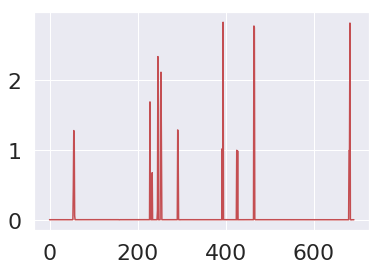

In [32]:
plt.figure()
plt.plot(testY, 'r')
# plt.plot(predict, 'g')
plt.show()